<h2 style="color: #ff00aa; font-size: 26px; text-align: center; margin-top: 20px; margin-bottom: 5px; font-family: 'Segoe UI', sans-serif; font-weight: 600;">Automated PIXE Spectrum Peak Identification Pipeline</h2>
<p style="color: #ff00aa; text-align: center; margin-top: 0; margin-bottom: 25px; font-size: 14px; font-weight: bold; text-transform: uppercase; letter-spacing: 1px;">José Sousa-Brito</p>

<h2 style="color: #ff00aa; font-size: 20px; font-family: 'Segoe UI', sans-serif; font-weight: 600; border-bottom: 2px solid #ff00aa; padding-bottom: 5px;">Pipeline Core Architecture</h2>

This pipeline automates the visualization of PIXE spectra by dynamically combining raw experimental ion beam counts with analytical peak evaluation:

| Functional Stage | Operational Protocol |
| :--- | :--- |
| **Dynamic Line Population** | Queries the `xraydb` atomic database in real-time, automatically converting theoretical transition energies from eV into keV. |
| **Metric Extraction** | Parses the corresponding GUPIXWin `_stats.txt` file using structural regular expressions to isolate target elements flagged as present (`"Y"` or `"?"`). |
| **Logarithmic Rendering** | Plots the experimental matrix alongside the analytical fit curve on a logarithmic scale, dynamically shifting boundaries to capture minor traces without clipping high-yield structures. |
| **Bracket Annotation** | Calculates local maxima for adjacent transitions, dropping vertical tracking links to characteristic lines and clustering them via overhead bounding brackets. |

---

<h2 style="color: #ff00aa; font-size: 20px; font-family: 'Segoe UI', sans-serif; font-weight: 600; border-bottom: 2px solid #ff00aa; padding-bottom: 5px;">Configuration & Dataset Deployment</h2>

To adapt the execution parameters to a different experimental dataset, adjust the dedicated config properties at the top of the script structure:

### 1. Data Ingestion Paths

Provide absolute system directories targeting the text raw matrix and its matching evaluation summary:

```python
FILE_PATH_GRAPH = r'C:\Users\joseb\Desktop\...\672023.txt'
FILE_PATH_STATS = r'C:\Users\joseb\Desktop\...\672023_stats.txt'
```

### 2. Region of Interest Boundaries

Isolate specific evaluation windows by setting the energy boundary cut-offs (in keV):

```python
X_MIN, X_MAX = 0.7, 9.5  # Restricts window range
```

### 3. Atomic Transition Line Filters
Declare specific characteristic X-ray transitions to monitor or filter for each element:

```python
ELEMENT_LINE_MAPPING = {
    "Fe": ["Ka1", "Ka2", "Kb1", "Kb3"],  # K-shell transitions
    "Ba": ["La1", "Lb1", "Lb2"],        # L-shell transitions
}
```

### 4. Layout Adjustments & Aesthetic Fine-Tuning

Override automated placements if graphical artifacts or text clusters collide or intersect with dataset peak traces:

- **MANUAL_HEIGHTS:** Forces custom ceiling parameters for bounding elements. Set a baseline multiplier relative to the layout boundary ceiling.
- **MANUAL_LABELS:** Shunts crowded label headers left or right from standard configurations by a specific energy offset (in keV).

```python
MANUAL_HEIGHTS = {
    "Cu": 0.0015,
    "Ca": 0.00005,
    "Element": value,  # Add custom height entries here
}

MANUAL_LABELS = {
    "Zn": {"align": "right", "offset": 0.05},
}
```

### Output

For every processed dataset, the script exports a vector-based figure directly into the source directory. 

```python
output_pdf = FILE_PATH_GRAPH.replace(".txt", "_peaks.pdf")


Identified elements:
  Al
  Ca
  Cl
  Cu
  Fe
  K
  Mg
  Mn
  Na
  Ni
  P
  S
  Si
  Ti
  V
  Zn


Graph successfully saved to:
C:\Users\joseb\Desktop\G3_DATA_LUCKYSTRIKE_POLIMETALICNODODULS\Simulated_DATA\PIXE_SPECTRA\TRETA\672023_peaks.pdf


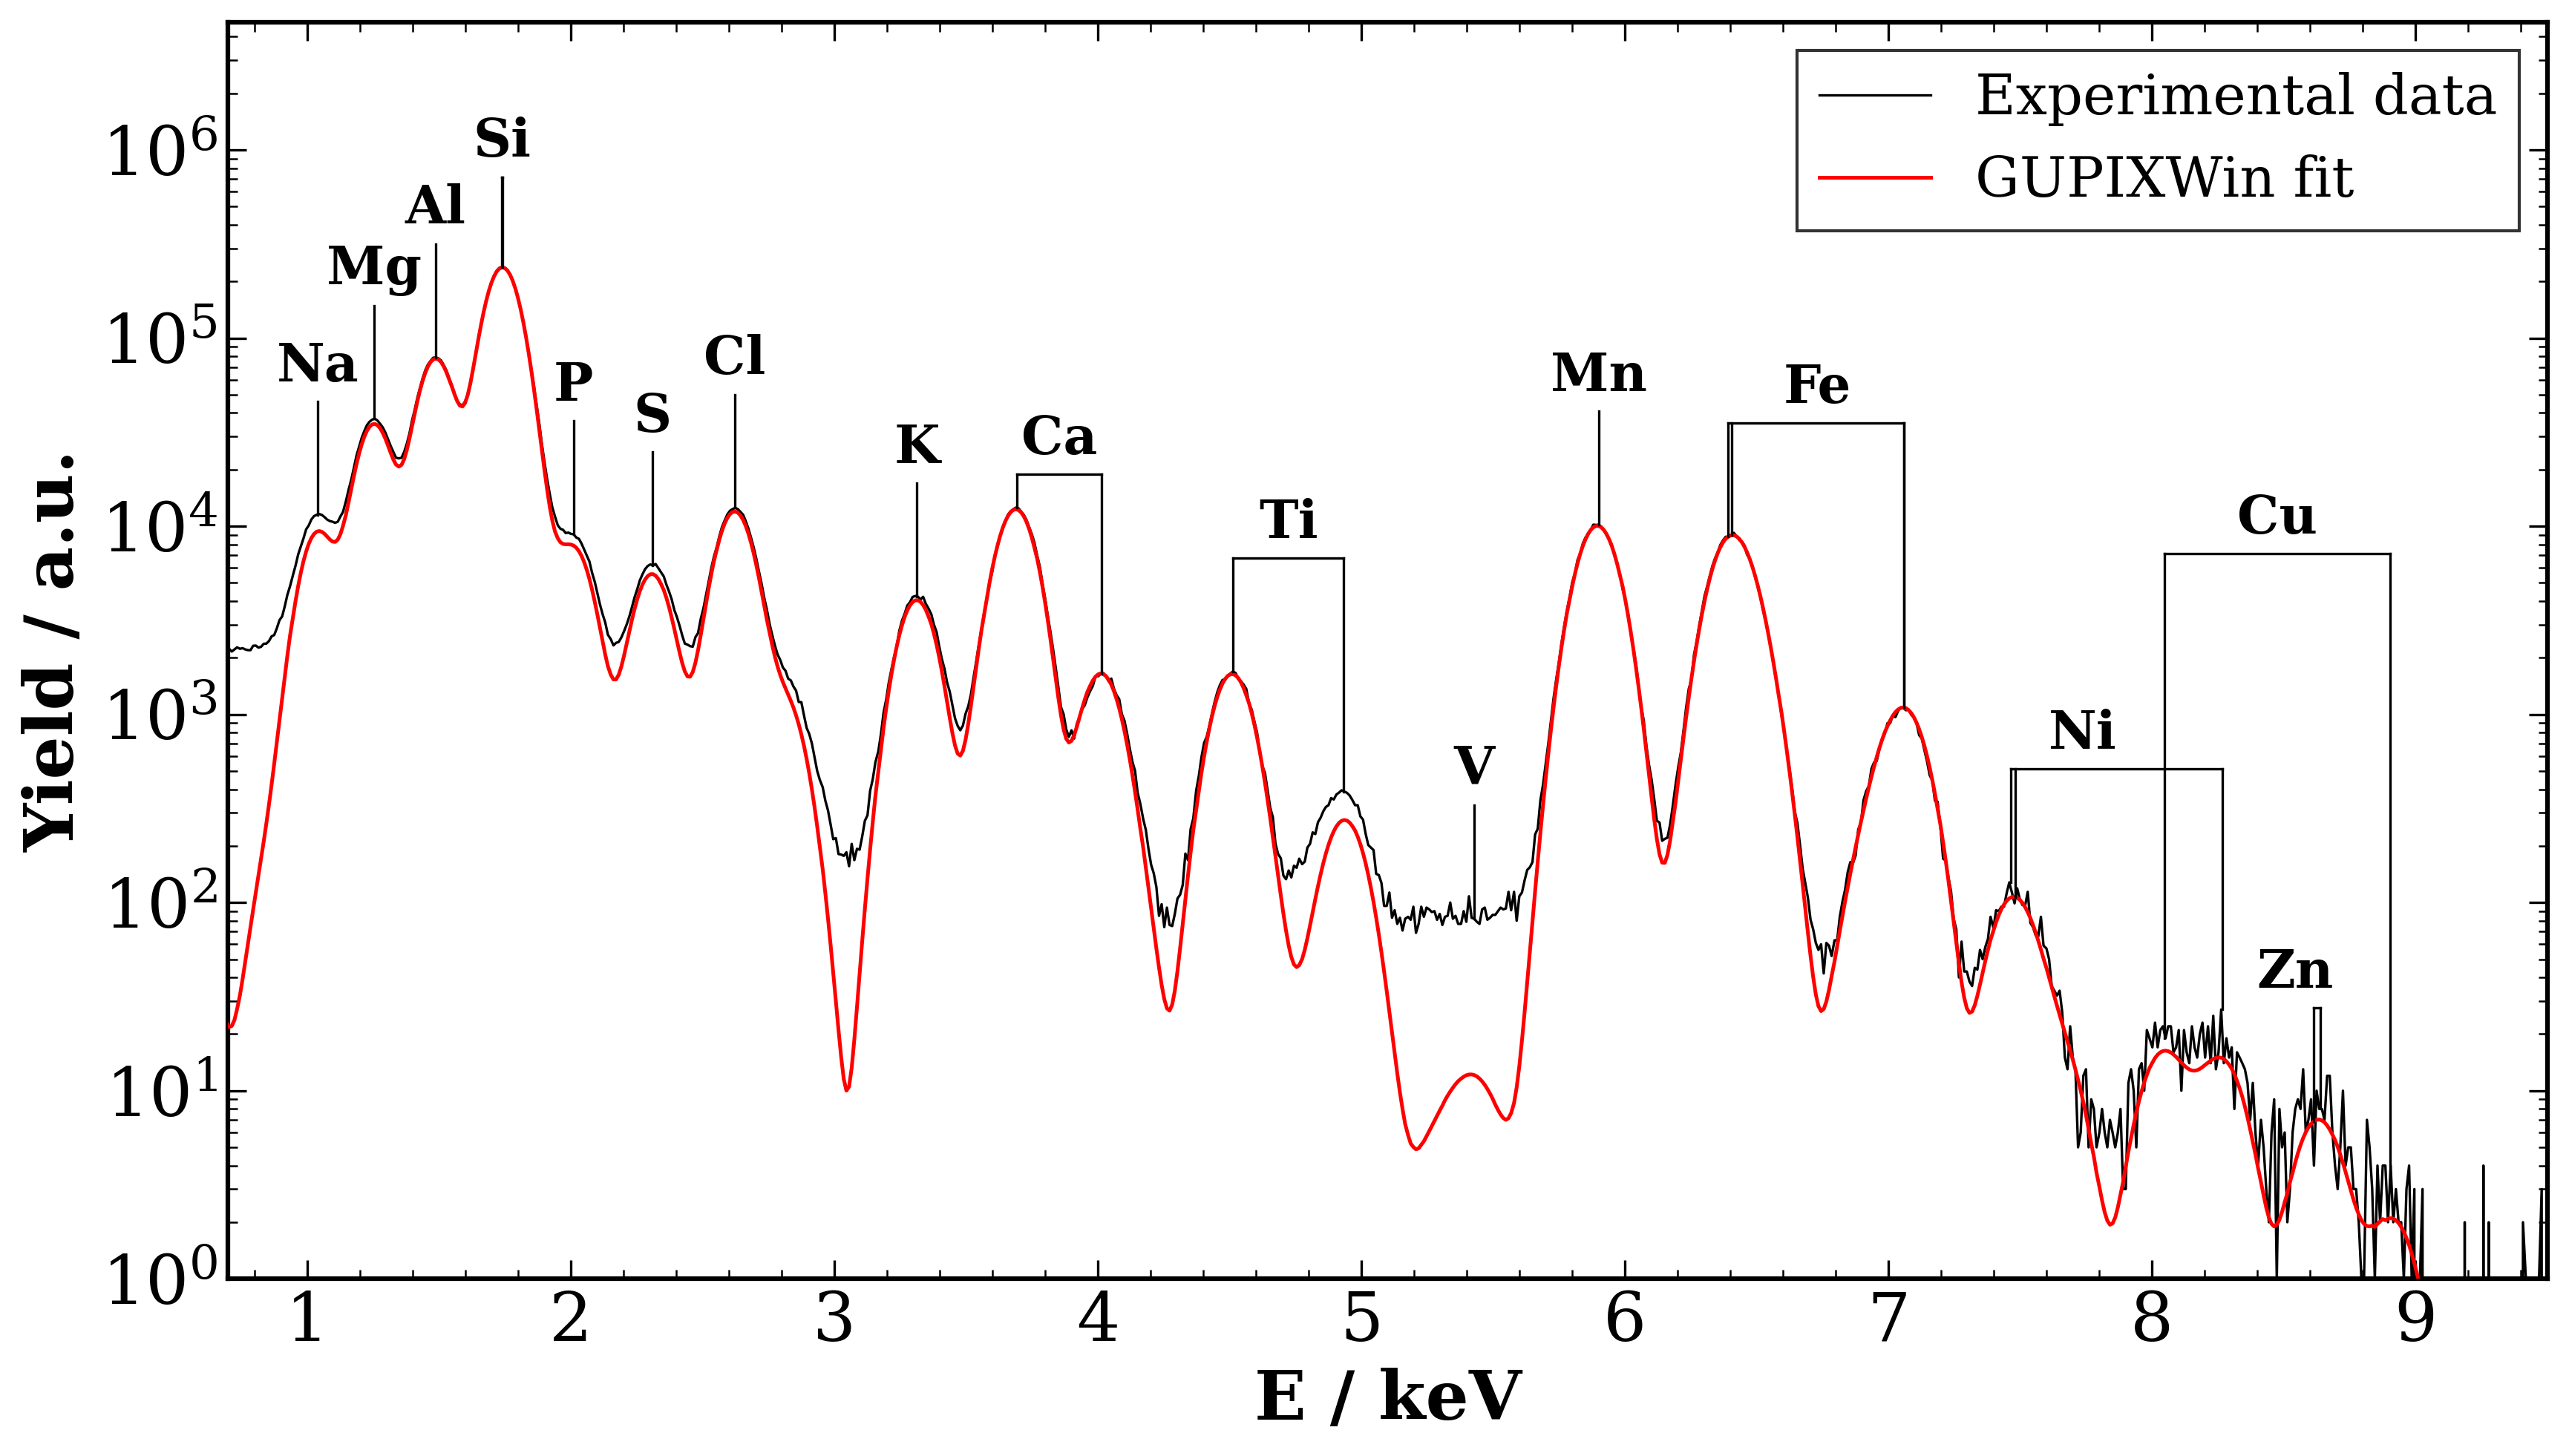

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import os
import re
import xraydb 

# Section 1

FILE_PATH_GRAPH = r'C:\Users\joseb\Desktop\G3_DATA_LUCKYSTRIKE_POLIMETALICNODODULS\Simulated_DATA\PIXE_SPECTRA\672023\672023.txt'
FILE_PATH_STATS = r'C:\Users\joseb\Desktop\G3_DATA_LUCKYSTRIKE_POLIMETALICNODODULS\Simulated_DATA\PIXE_SPECTRA\672023\672023_stats.txt'

X_MIN, X_MAX = 0.7, 9.5 # keV

# Section 2

# Define which transitions to cleanly extract for each element.
# xraydb uses standard nomenclature (e.g. 'Ka1', 'Ka2', 'Kb1', 'La1')

ELEMENT_LINE_MAPPING = {
    "Na": ["Ka1"],
    "Mg": ["Ka1"],
    "Al": ["Ka1"],
    "Si": ["Ka1", "Ka2"],
    "P":  ["Ka1"],
    "S":  ["Ka1"],
    "Cl": ["Ka1"],
    "K":  ["Ka1"],
    "Ca": ["Ka1", "Kb1"],
    "Ti": ["Ka1", "Kb1"],
    "V":  ["Kb1", "Kb2"],
    "Mn": ["Ka1"],
    "Fe": ["Ka1", "Ka2", "Kb1", "Kb3"],
    "Ni": ["Ka1", "Ka2", "Kb1"],
    "Cu": ["Ka1", "Kb1"],
    "Zn": ["Ka1", "Ka2"],
    "Ge": ["Ka1"],
    "As": ["Kb1", "Kb2", "Kb3"],
    "Br": ["Kb1"],
    "Rb": ["Ka1", "Ka2"],
    "Sr": ["Ka1", "Ka2", "Kb2"],
    "Mo": ["Ka1", "Ka2", "Kb1", "Kb2", "Kb3"],
    "Ba": ["La1", "Lb1", "Lb2"],
    "La": ["La1", "Lb1"],
}


XRAY_LINES = {}
for el, lines in ELEMENT_LINE_MAPPING.items():
    XRAY_LINES[el] = {}
    for line in lines:
        try:
            energy_kev = xraydb.xray_line(el, line).energy / 1000.0
            XRAY_LINES[el][line] = energy_kev
        except AttributeError:
            continue


# MANUAL FIXED HEIGHTS (Put elements that overlap with others)

MANUAL_HEIGHTS = {
    "Cu": 0.0015,  
    "Ca": 0.00005,  
}

# You can also manually adjust the label positions for specific elements if needed.

MANUAL_LABELS = {
    "Zn": {"align": "right", "offset": 0.05},  
}


plt.rcParams.update({
    "font.family": "serif",
    "font.size": 22,
    "axes.linewidth": 1.5,
    "figure.dpi": 300,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,
    "axes.labelsize": 22,
    "legend.fontsize": 18,
})


def load_pixe_data(path):
    data = []
    with open(path, "r") as f:
        for line in f:
            line = line.strip().replace(",", "")
            if not line or line.startswith("[") or "Channel" in line:
                continue
            parts = line.split()
            if len(parts) >= 4 and parts[0].isdigit():
                try:
                    data.append([float(parts[1]), float(parts[2]), float(parts[3])])
                except:
                    continue
    return np.array(data)


def extract_stats_elements(path):
    elements = set()
    if not os.path.exists(path):
        print("Stats file not found.")
        return []
    with open(path, "r", encoding="latin-1") as f:
        lines = f.readlines()
    print("\nIdentified elements:")
    for line in lines:
        line = line.strip()
        if not (line.endswith("Y") or line.endswith("?")):
            continue
        match = re.match(r'^\s*\d+\s+([A-Za-z]{1,2})', line)
        if not match:
            continue
        symbol = match.group(1).capitalize()
        if symbol in XRAY_LINES:
            elements.add(symbol)
    elements = sorted(list(elements))
    for el in elements:
        print(f"  {el}")
    print()
    return elements


def plot_spectrum(data, elements):
    energy       = data[:, 0]
    experimental = data[:, 1]
    fit          = data[:, 2]

    fig, ax = plt.subplots(figsize=(12, 7))

    ax.plot(energy, experimental, color="black", lw=0.8,
            label="Experimental data", zorder=2)
    ax.plot(energy, fit,          color="red",   lw=1.2,
            label="GUPIXWin fit",    zorder=3)

    ax.set_xlabel("E / keV", fontweight="bold")
    ax.set_ylabel("Yield / a.u.", fontweight="bold")
    ax.set_xlim(X_MIN, X_MAX)
    ax.set_yscale("log")

    y_max = max(np.nanmax(experimental), np.nanmax(fit))
    y_axis_top = y_max * 20
    ax.set_ylim(1, y_axis_top)

    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())


    for element in elements:
        if element not in XRAY_LINES:
            continue

        lines = XRAY_LINES[element]
        energies = sorted([e for e in lines.values() if X_MIN < e < X_MAX])
        if not energies:
            continue

        x_left   = min(energies)
        x_right  = max(energies)

    
        idx_main = np.argmin(np.abs(energy - energies[0]))
        y_peak   = max(fit[idx_main], experimental[idx_main], 1.0)

        if element in MANUAL_HEIGHTS:
            y_top = MANUAL_HEIGHTS[element] * y_axis_top
        else:
        
            y_top = min(y_peak * 4, y_axis_top * 0.15)

        y_top = max(y_top, y_peak * 1.5)
        y_text = y_top * 1.12

        for e_keV in energies:
            idx        = np.argmin(np.abs(energy - e_keV))
            y_local_pk = max(fit[idx], experimental[idx], 1.0)
            ax.plot([e_keV, e_keV], [y_local_pk, y_top],
                    color="black", lw=0.8, zorder=4)

        if len(energies) > 1:
            ax.plot([x_left, x_right], [y_top, y_top],
                    color="black", lw=0.8, zorder=4)

        x_text = np.mean(energies) 
        ha_mode = "center"        

        if element in MANUAL_LABELS:
            config = MANUAL_LABELS[element]
            ha_mode = config.get("align", "center")
            offset = config.get("offset", 0.0)
            
            if ha_mode == "left":
                x_text = x_left + offset
            elif ha_mode == "right":
                x_text = x_right + offset

        ax.text(x_text, y_text, element,
                ha=ha_mode, va="bottom",
                fontsize=17, fontweight="bold", zorder=5)

    ax.legend(loc="upper right", frameon=True,
              edgecolor="black", fancybox=False)

    plt.tight_layout()

    output_pdf = FILE_PATH_GRAPH.replace(".txt", "_peaks.pdf")
    plt.savefig(output_pdf, format="pdf", bbox_inches="tight")
    print(f"\nGraph successfully saved to:\n{output_pdf}")
    plt.show()

if __name__ == "__main__":
    if not os.path.isfile(FILE_PATH_GRAPH):
        print("Spectrum data file not found.")
    else:
        dataset  = load_pixe_data(FILE_PATH_GRAPH)
        elements = extract_stats_elements(FILE_PATH_STATS)
        if len(dataset) == 0:
            print("Error parsing spectrum data matrix.")
        else:
            plot_spectrum(dataset, elements)